In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/world-happiness/2015.csv
/kaggle/input/world-happiness/2017.csv
/kaggle/input/world-happiness/2019.csv
/kaggle/input/world-happiness/2018.csv
/kaggle/input/world-happiness/2016.csv


# import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# load dataset

In [3]:
df = pd.read_csv("/kaggle/input/world-happiness/2019.csv")
df

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


# Explore data

In [4]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:
df . tail()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


In [6]:
df . shape

(156, 9)

In [7]:
df . columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [8]:
df . info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [9]:
df . describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [10]:
df.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

# Analyzing Happiness Score

In [11]:
df['Score'].mean(), df['Score'].min(), df['Score'].max()

(np.float64(5.407096153846155), 2.853, 7.769)

In [12]:
df_sorted = df.sort_values(by='Score', ascending=False)
df_sorted[['Country or region', 'Score']].head(10)

,Country or region,Score
0,Finland,7.769
1,Denmark,7.600
2,Norway,7.554
3,Iceland,7.494
4,Netherlands,7.488
5,Switzerland,7.480
6,Sweden,7.343
7,New Zealand,7.307
8,Canada,7.278
9,Austria,7.246


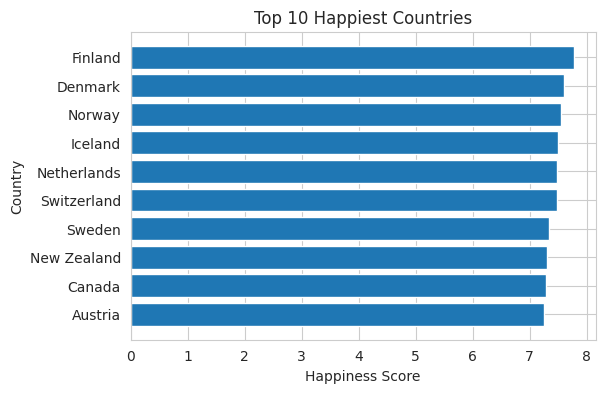

In [13]:
top10 = df_sorted.head(10)
plt.figure(figsize=(6,4))
plt.barh(top10['Country or region'], top10['Score'])
plt.title("Top 10 Happiest Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

In [14]:
df['GDP per capita'].mean(), df['GDP per capita'].min(), df['GDP per capita'].max()

(np.float64(0.905147435897436), 0.0, 1.684)

In [15]:
df_sorted_gdp = df.sort_values(by='GDP per capita', ascending=False)
df_sorted_gdp[['Country or region', 'GDP per capita']].head(10)

,Country or region,GDP per capita
28,Qatar,1.684
13,Luxembourg,1.609
33,Singapore,1.572
20,United Arab Emirates,1.503
50,Kuwait,1.500
15,Ireland,1.499
2,Norway,1.488
5,Switzerland,1.452
75,Hong Kong,1.438
18,United States,1.433


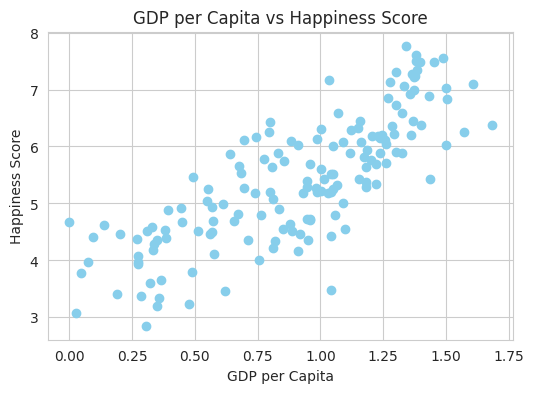

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df['GDP per capita'], df['Score'], color='skyblue')
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

# Freedom Analysis

In [17]:
df['Freedom to make life choices'].agg(['count', 'mean', 'min', 'max', 'std'])


count    156.000000
mean       0.392571
min        0.000000
max        0.631000
std        0.143289
Name: Freedom to make life choices, dtype: float64

In [18]:
highest_freedom = df.sort_values(by='Freedom to make life choices', ascending=False).head(5)[['Country or region','Freedom to make life choices']]

In [19]:
lowest_freedom = df.sort_values(by='Freedom to make life choices', ascending=True).head(5)[['Country or region','Freedom to make life choices']]
highest_freedom, lowest_freedom

(        Country or region  Freedom to make life choices
 40             Uzbekistan                         0.631
 108              Cambodia                         0.609
 2                  Norway                         0.603
 20   United Arab Emirates                         0.598
 0                 Finland                         0.596,
     Country or region  Freedom to make life choices
 153       Afghanistan                         0.000
 155       South Sudan                         0.010
 148             Syria                         0.013
 146             Haiti                         0.026
 121        Mauritania                         0.066)

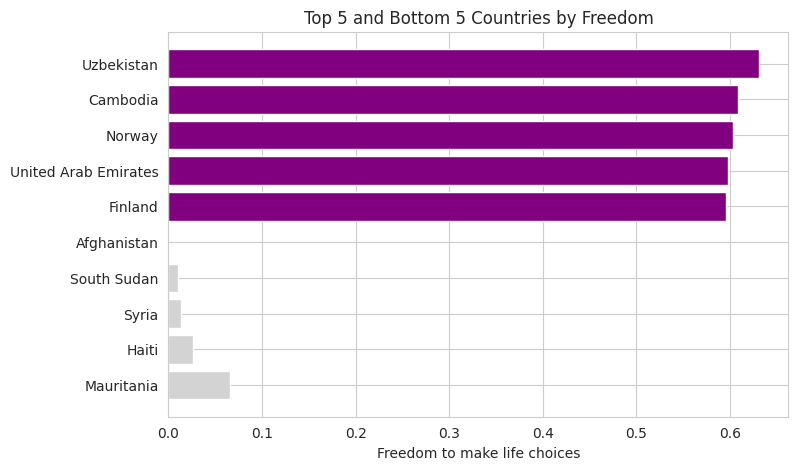

In [20]:
extreme_freedom = pd.concat([highest_freedom, lowest_freedom])

plt.figure(figsize=(8,5))
plt.barh(extreme_freedom['Country or region'], extreme_freedom['Freedom to make life choices'], color=['purple']*5 + ['lightgray']*5)
plt.xlabel("Freedom to make life choices")
plt.title("Top 5 and Bottom 5 Countries by Freedom")
plt.gca().invert_yaxis()
plt.show()

In [21]:
df['Generosity'].mean(), df['Generosity'].min(), df['Generosity'].max()

(np.float64(0.18484615384615383), 0.0, 0.566)

In [22]:
top5_generosity = df.sort_values(by='Generosity', ascending=False).head(5)[['Country or region','Generosity']]
bottom5_generosity = df.sort_values(by='Generosity', ascending=True).head(5)[['Country or region','Generosity']]
top5_generosity, bottom5_generosity

(    Country or region  Generosity
 130           Myanmar       0.566
 91          Indonesia       0.498
 146             Haiti       0.419
 21              Malta       0.375
 120             Kenya       0.372,
     Country or region  Generosity
 81             Greece       0.000
 147          Botswana       0.025
 89         Azerbaijan       0.035
 88            Morocco       0.036
 103             Gabon       0.043)

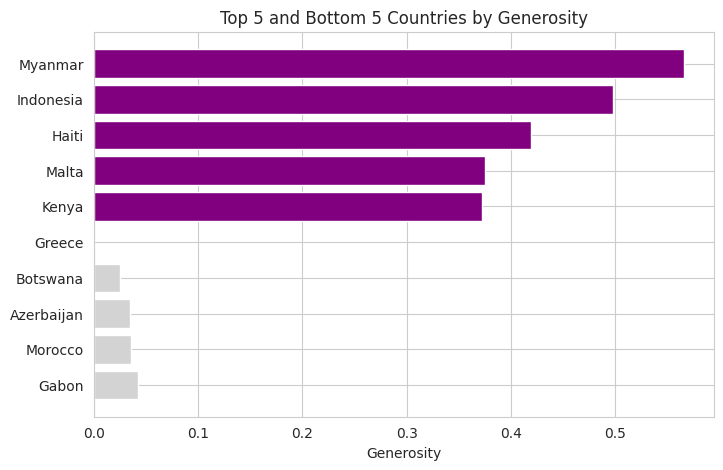

In [23]:
extreme_generosity = pd.concat([top5_generosity, bottom5_generosity])
plt.figure(figsize=(8,5))
plt.barh(extreme_generosity['Country or region'], extreme_generosity['Generosity'], color=['purple']*5 + ['lightgray']*5)
plt.xlabel("Generosity")
plt.title("Top 5 and Bottom 5 Countries by Generosity")
plt.gca().invert_yaxis()
plt.show()

In [24]:
df['Score'].describe()

count    156.000000
mean       5.407096
std        1.113120
min        2.853000
25%        4.544500
50%        5.379500
75%        6.184500
max        7.769000
Name: Score, dtype: float64

In [25]:
top5_happiness = df.sort_values('Score', ascending=False).head(5)[['Country or region','Score']]
bottom5_happiness = df.sort_values('Score', ascending=True).head(5)[['Country or region','Score']]
top5_happiness, bottom5_happiness

(  Country or region  Score
 0           Finland  7.769
 1           Denmark  7.600
 2            Norway  7.554
 3           Iceland  7.494
 4       Netherlands  7.488,
             Country or region  Score
 155               South Sudan  2.853
 154  Central African Republic  3.083
 153               Afghanistan  3.203
 152                  Tanzania  3.231
 151                    Rwanda  3.334)

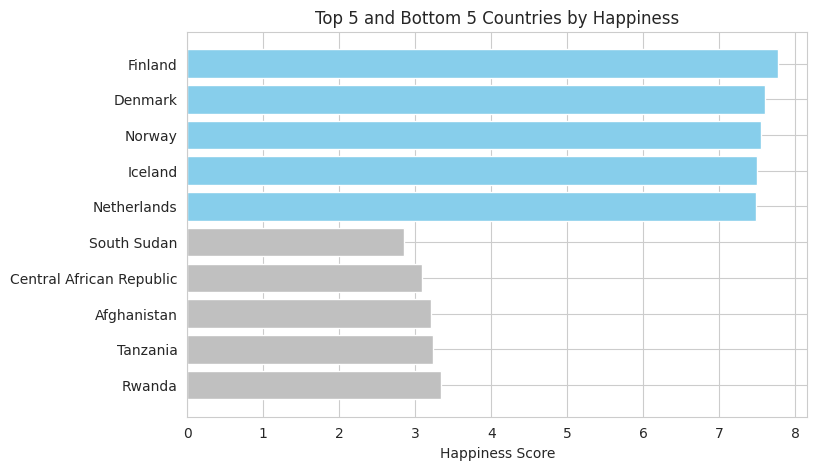

In [26]:
plt.figure(figsize=(8,5))
plt.barh(top5_happiness['Country or region'], top5_happiness['Score'], color='skyblue')
plt.barh(bottom5_happiness['Country or region'], bottom5_happiness['Score'], color='silver')
plt.xlabel("Happiness Score")
plt.title("Top 5 and Bottom 5 Countries by Happiness")
plt.gca().invert_yaxis()
plt.show()

# Quick Insights from Dataset

In [27]:
df[['Country or region', 'Score']].sort_values(by='Score', ascending=False).head(5)

,Country or region,Score
0,Finland,7.769
1,Denmark,7.600
2,Norway,7.554
3,Iceland,7.494
4,Netherlands,7.488


In [28]:
df.groupby('Country or region')['Score'].mean().sort_values(ascending=False).head(10)

Country or region
Finland        7.769
Denmark        7.600
Norway         7.554
Iceland        7.494
Netherlands    7.488
Switzerland    7.480
Sweden         7.343
New Zealand    7.307
Canada         7.278
Austria        7.246
Name: Score, dtype: float64

In [29]:
df[['Country or region','GDP per capita','Score']].sort_values(by='GDP per capita', ascending=False).head(5)

,Country or region,GDP per capita,Score
28,Qatar,1.684,6.374
13,Luxembourg,1.609,7.090
33,Singapore,1.572,6.262
20,United Arab Emirates,1.503,6.825
50,Kuwait,1.500,6.021


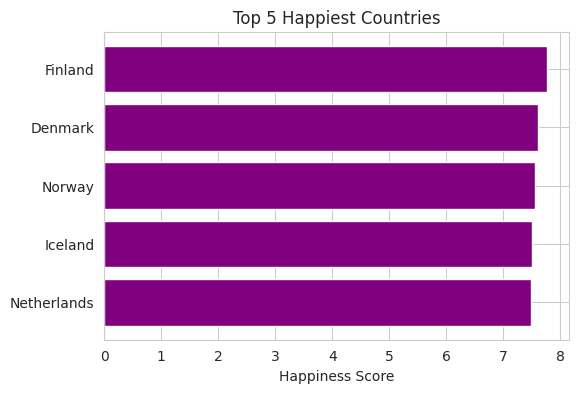

In [30]:
top5_happiness = df[['Country or region','Score']].sort_values(by='Score', ascending=False).head(5)

plt.figure(figsize=(6,4))
plt.barh(top5_happiness['Country or region'], top5_happiness['Score'], color='purple')
plt.xlabel("Happiness Score")
plt.title("Top 5 Happiest Countries")
plt.gca().invert_yaxis()
plt.show()


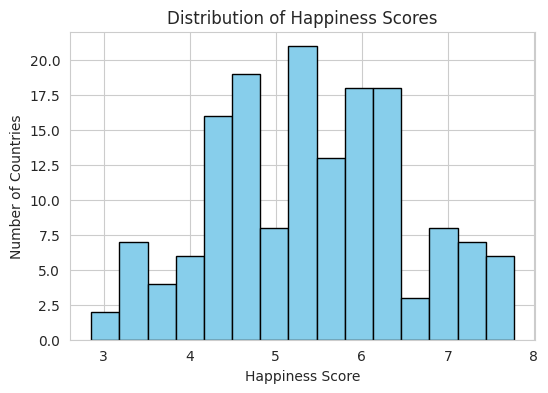

In [31]:
plt.figure(figsize=(6,4))
plt.hist(df['Score'], bins=15, color='skyblue', edgecolor='black')
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")
plt.show()


In [32]:
df[['Country or region', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity']].sort_values(by='GDP per capita', ascending=False).head(5)

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity
28,Qatar,1.684,1.313,0.871,0.555,0.220
13,Luxembourg,1.609,1.479,1.012,0.526,0.194
33,Singapore,1.572,1.463,1.141,0.556,0.271
20,United Arab Emirates,1.503,1.310,0.825,0.598,0.262
50,Kuwait,1.500,1.319,0.808,0.493,0.142


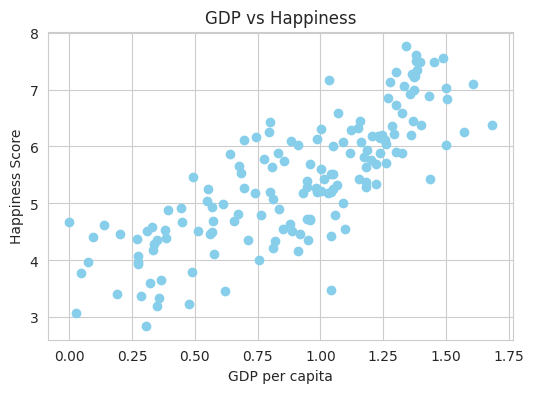

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(df['GDP per capita'], df['Score'], color='skyblue')
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.title("GDP vs Happiness")
plt.show()